In [2]:
#04_bbox_roi_region_growing.ipynb

# Step 4 - BBox ROI Extraction and Region Growing Refinement

In this step, the bounding box is no longer used as the final mask.
Instead, it is used as a region of interest (ROI) to localize the lesion area.

A region growing algorithm is then applied from the transformed lesion center to obtain a refined mask that better follows the lesion structure.

In [18]:
# ============================================================
# STEP 1 - Build Master DataFrame
# ============================================================

!pip install pandas nibabel matplotlib scipy -q

import os
import glob
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
BASE = "/content/drive/MyDrive/MELA"

TRAIN_DIR = os.path.join(BASE, "images", "train")
VAL_DIR   = os.path.join(BASE, "images", "val")

ANN_PATH     = os.path.join(BASE, "annotations", "mela_train_val_annotations.csv")
SPACING_PATH = os.path.join(BASE, "annotations", "mela_origin_spacing.csv")

print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("ANN_PATH:", ANN_PATH)
print("SPACING_PATH:", SPACING_PATH)

# ------------------------------------------------------------
# LOAD CSV FILES
# ------------------------------------------------------------
df_ann = pd.read_csv(ANN_PATH)
df_spacing = pd.read_csv(SPACING_PATH)

df_ann.columns = [c.strip() for c in df_ann.columns]
df_spacing.columns = [c.strip() for c in df_spacing.columns]

print("\nAnnotation shape:", df_ann.shape)
print("Spacing shape:", df_spacing.shape)

print("\nAnnotation columns:", df_ann.columns.tolist())
print("Spacing columns:", df_spacing.columns.tolist())

# ------------------------------------------------------------
# BUILD FILE MAPS
# ------------------------------------------------------------
train_files = sorted(glob.glob(os.path.join(TRAIN_DIR, "*.nii.gz")))
val_files   = sorted(glob.glob(os.path.join(VAL_DIR, "*.nii.gz")))

train_map = {
    os.path.basename(path).replace(".nii.gz", ""): path
    for path in train_files
}

val_map = {
    os.path.basename(path).replace(".nii.gz", ""): path
    for path in val_files
}

print("\nTrain file count:", len(train_map))
print("Val file count:", len(val_map))

# ------------------------------------------------------------
# RESOLVE IMAGE PATH + SPLIT
# ------------------------------------------------------------
def resolve_image_info(public_id):
    if public_id in train_map:
        return pd.Series([train_map[public_id], "train"])
    elif public_id in val_map:
        return pd.Series([val_map[public_id], "val"])
    else:
        return pd.Series([None, "missing"])

df_ann[["image_path", "split"]] = df_ann["public_id"].apply(resolve_image_info)

# ------------------------------------------------------------
# MERGE TABLES
# ------------------------------------------------------------
df_master = pd.merge(df_ann, df_spacing, on="public_id", how="left")

# ------------------------------------------------------------
# TYPE CLEANUP
# ------------------------------------------------------------
int_cols = ["coordX", "coordY", "coordZ", "x_length", "y_length", "z_length"]
float_cols = ["origin_x", "origin_y", "origin_z", "spacing_x", "spacing_y", "spacing_z"]

for col in int_cols:
    df_master[col] = pd.to_numeric(df_master[col], errors="coerce")

for col in float_cols:
    df_master[col] = pd.to_numeric(df_master[col], errors="coerce")

# ------------------------------------------------------------
# EXTRA COLUMNS
# ------------------------------------------------------------
df_master["x1"] = df_master["coordX"]
df_master["y1"] = df_master["coordY"]
df_master["z1"] = df_master["coordZ"]

df_master["x2"] = df_master["coordX"] + df_master["x_length"]
df_master["y2"] = df_master["coordY"] + df_master["y_length"]
df_master["z2"] = df_master["coordZ"] + df_master["z_length"]

df_master["center_x"] = df_master["coordX"] + df_master["x_length"] / 2.0
df_master["center_y"] = df_master["coordY"] + df_master["y_length"] / 2.0
df_master["center_z"] = df_master["coordZ"] + df_master["z_length"] / 2.0

df_master["size_mm_x"] = df_master["x_length"] * df_master["spacing_x"]
df_master["size_mm_y"] = df_master["y_length"] * df_master["spacing_y"]
df_master["size_mm_z"] = df_master["z_length"] * df_master["spacing_z"]

# ------------------------------------------------------------
# REPORT
# ------------------------------------------------------------
print("\n===== MASTER DATAFRAME INFO =====")
print("Total rows:", len(df_master))
print("\nSplit counts:")
print(df_master["split"].value_counts(dropna=False))

missing = df_master[df_master["split"] == "missing"]
print("\nMissing image matches:", len(missing))

print("\nUnique public_id:", df_master["public_id"].nunique())
print("Duplicate public_id count:", df_master["public_id"].duplicated().sum())

print("\nFirst 5 rows:")
display(df_master.head())

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
MASTER_PATH = os.path.join(BASE, "annotations", "mela_master_dataframe.csv")
df_master.to_csv(MASTER_PATH, index=False)

print("\nSaved master dataframe to:")
print(MASTER_PATH)

TRAIN_DIR: /content/drive/MyDrive/MELA/images/train
VAL_DIR: /content/drive/MyDrive/MELA/images/val
ANN_PATH: /content/drive/MyDrive/MELA/annotations/mela_train_val_annotations.csv
SPACING_PATH: /content/drive/MyDrive/MELA/annotations/mela_origin_spacing.csv

Annotation shape: (884, 7)
Spacing shape: (880, 7)

Annotation columns: ['public_id', 'coordX', 'coordY', 'coordZ', 'x_length', 'y_length', 'z_length']
Spacing columns: ['public_id', 'origin_x', 'origin_y', 'origin_z', 'spacing_x', 'spacing_y', 'spacing_z']

Train file count: 260
Val file count: 110

===== MASTER DATAFRAME INFO =====
Total rows: 884

Split counts:
split
missing    512
train      262
val        110
Name: count, dtype: int64

Missing image matches: 512

Unique public_id: 880
Duplicate public_id count: 4

First 5 rows:


,public_id,coordX,coordY,coordZ,x_length,y_length,z_length,image_path,split,origin_x,...,z1,x2,y2,z2,center_x,center_y,center_z,size_mm_x,size_mm_y,size_mm_z
0,mela_0001,300,153,278,62,61,37,/content/drive/MyDrive/MELA/images/train/mela_...,train,-162.130005,...,278,362,214,315,331.0,183.5,296.5,37.539062,36.933594,37.000000
1,mela_0002,265,182,274,42,39,38,/content/drive/MyDrive/MELA/images/train/mela_...,train,-181.210083,...,274,307,221,312,286.0,201.5,293.0,30.515625,28.335938,38.000000
2,mela_0003,259,269,315,111,81,100,/content/drive/MyDrive/MELA/images/train/mela_...,train,-157.666016,...,315,370,350,415,314.5,309.5,365.0,74.144531,54.105469,70.001221
3,mela_0004,317,309,360,112,115,138,/content/drive/MyDrive/MELA/images/train/mela_...,train,-199.605469,...,360,429,424,498,373.0,366.5,429.0,88.375000,90.742188,96.597473
4,mela_0005,284,187,345,40,59,54,/content/drive/MyDrive/MELA/images/train/mela_...,train,-179.621094,...,345,324,246,399,304.0,216.5,372.0,30.312500,44.710938,37.799835



Saved master dataframe to:
/content/drive/MyDrive/MELA/annotations/mela_master_dataframe.csv


In [19]:
# ============================================================
# STEP 2 - Filter Valid Samples + Lesion Slice Ranges
# ============================================================

# Sadece mevcut image'lara sahip örnekler
df_valid = df_master[df_master["split"] != "missing"].copy()

print("Valid rows before dedup:", len(df_valid))

# Aynı public_id tekrar ediyorsa ilkini al
df_valid = df_valid.drop_duplicates(subset=["public_id"]).copy()

print("Valid rows after dedup:", len(df_valid))
print("Unique public_id after dedup:", df_valid["public_id"].nunique())

# Lesion slice range
df_valid["z_min"] = df_valid["coordZ"].astype(int)
df_valid["z_max"] = (df_valid["coordZ"] + df_valid["z_length"]).astype(int)

# Güvenlik için sıra düzeltme
df_valid["z_min"] = df_valid[["z_min", "z_max"]].min(axis=1)
df_valid["z_max"] = df_valid[["z_min", "z_max"]].max(axis=1)

print("\nSplit counts in valid set:")
print(df_valid["split"].value_counts())

print("\nSample lesion slice ranges:")
display(df_valid[[
    "public_id", "split",
    "coordX", "coordY", "coordZ",
    "x_length", "y_length", "z_length",
    "z_min", "z_max",
    "image_path"
]].head(10))

# İstersen kaydet
VALID_PATH = os.path.join(BASE, "annotations", "mela_valid_samples.csv")
df_valid.to_csv(VALID_PATH, index=False)

print("\nSaved valid sample table to:")
print(VALID_PATH)

Valid rows before dedup: 372
Valid rows after dedup: 370
Unique public_id after dedup: 370

Split counts in valid set:
split
train    260
val      110
Name: count, dtype: int64

Sample lesion slice ranges:


,public_id,split,coordX,coordY,coordZ,x_length,y_length,z_length,z_min,z_max,image_path
0,mela_0001,train,300,153,278,62,61,37,278,315,/content/drive/MyDrive/MELA/images/train/mela_...
1,mela_0002,train,265,182,274,42,39,38,274,312,/content/drive/MyDrive/MELA/images/train/mela_...
2,mela_0003,train,259,269,315,111,81,100,315,415,/content/drive/MyDrive/MELA/images/train/mela_...
3,mela_0004,train,317,309,360,112,115,138,360,498,/content/drive/MyDrive/MELA/images/train/mela_...
4,mela_0005,train,284,187,345,40,59,54,345,399,/content/drive/MyDrive/MELA/images/train/mela_...
5,mela_0006,train,266,155,329,32,38,50,329,379,/content/drive/MyDrive/MELA/images/train/mela_...
6,mela_0007,train,321,225,282,191,179,210,282,492,/content/drive/MyDrive/MELA/images/train/mela_...
7,mela_0008,train,240,194,374,40,28,48,374,422,/content/drive/MyDrive/MELA/images/train/mela_...
8,mela_0009,train,268,220,356,35,38,38,356,394,/content/drive/MyDrive/MELA/images/train/mela_...
9,mela_0010,train,273,187,365,19,18,20,365,385,/content/drive/MyDrive/MELA/images/train/mela_...



Saved valid sample table to:
/content/drive/MyDrive/MELA/annotations/mela_valid_samples.csv


Sample: mela_0007
Image path: /content/drive/MyDrive/MELA/images/train/mela_0007.nii.gz
coord = (321, 225, 282)
length = (191, 179, 210)
Original shape: (512, 512, 460)
Canonical shape: (512, 512, 460)
Canonical center: (np.float64(94.49999999999997), np.float64(196.5), np.float64(387.0))
BBox bounds:
x: (0, 190)
y: (107, 286)
z: (282, 460)
z_show: 387


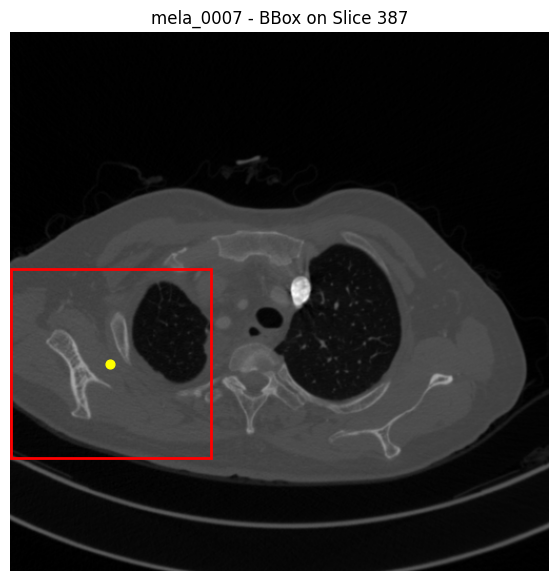

In [20]:
# ============================================================
# STEP 3 - Visualize BBox on a Single Sample
# ============================================================

import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ------------------------------------------------------------
# SAMPLE SELECTION
# ------------------------------------------------------------
sample_id = "mela_0007"   # istediğin sample ile değiştir

row = df_valid[df_valid["public_id"] == sample_id]
if len(row) == 0:
    raise ValueError(f"Sample bulunamadı: {sample_id}")

row = row.iloc[0]

image_path = row["image_path"]
coordX, coordY, coordZ = int(row["coordX"]), int(row["coordY"]), int(row["coordZ"])
lx, ly, lz = int(row["x_length"]), int(row["y_length"]), int(row["z_length"])

print("Sample:", sample_id)
print("Image path:", image_path)
print("coord =", (coordX, coordY, coordZ))
print("length =", (lx, ly, lz))

# ------------------------------------------------------------
# LOAD IMAGE + CANONICAL
# ------------------------------------------------------------
img = nib.load(image_path)
img_canon = nib.as_closest_canonical(img)
img_data = img_canon.get_fdata().astype(np.float32)

print("Original shape:", img.shape)
print("Canonical shape:", img_data.shape)

# ------------------------------------------------------------
# TRANSFORM BBOX CENTER TO CANONICAL
# ------------------------------------------------------------
center_old_voxel = np.array([
    coordX + lx / 2.0,
    coordY + ly / 2.0,
    coordZ + lz / 2.0,
    1.0
], dtype=np.float32)

center_world = img.affine @ center_old_voxel
center_new_voxel = np.linalg.inv(img_canon.affine) @ center_world

cx, cy, cz = center_new_voxel[:3]

print("Canonical center:", (cx, cy, cz))

# ------------------------------------------------------------
# BBOX LIMITS IN CANONICAL SPACE
# ------------------------------------------------------------
x_min = max(0, int(np.floor(cx - lx / 2.0)))
x_max = min(img_data.shape[0], int(np.ceil(cx + lx / 2.0)))

y_min = max(0, int(np.floor(cy - ly / 2.0)))
y_max = min(img_data.shape[1], int(np.ceil(cy + ly / 2.0)))

z_min = max(0, int(np.floor(cz - lz / 2.0)))
z_max = min(img_data.shape[2], int(np.ceil(cz + lz / 2.0)))

z_show = int(round(cz))

print("BBox bounds:")
print("x:", (x_min, x_max))
print("y:", (y_min, y_max))
print("z:", (z_min, z_max))
print("z_show:", z_show)

# ------------------------------------------------------------
# VISUALIZE
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(img_data[:, :, z_show].T, cmap="gray", origin="lower")

rect = patches.Rectangle(
    (x_min, y_min),
    x_max - x_min,
    y_max - y_min,
    linewidth=2,
    edgecolor="red",
    facecolor="none"
)
ax.add_patch(rect)

ax.scatter(cx, cy, c="yellow", s=40)
ax.set_title(f"{sample_id} - BBox on Slice {z_show}")
ax.axis("off")
plt.show()

Sample: mela_0007
coord = (321, 225, 282)
length = (191, 179, 210)
Canonical center: (np.float64(94.49999999999997), np.float64(196.5), np.float64(387.0))
ROI bounds: (0, 190, 107, 286, 282, 460)
ROI shape: (190, 179, 178)
Center seed in ROI: (94, 89, 105)
Local intensity seed in ROI: (np.int64(87), np.int64(94), np.int64(108))
Seed offset from center: (np.int64(-7), np.int64(5), np.int64(3))
Seed value: 88.41169738769531
Threshold range: (70.41169738769531, 106.41169738769531)
Binary voxel count: 195281
Connected voxel count: 94102
Chosen component distance from center: 10.295590496589764
Method used: fallback_inner_box


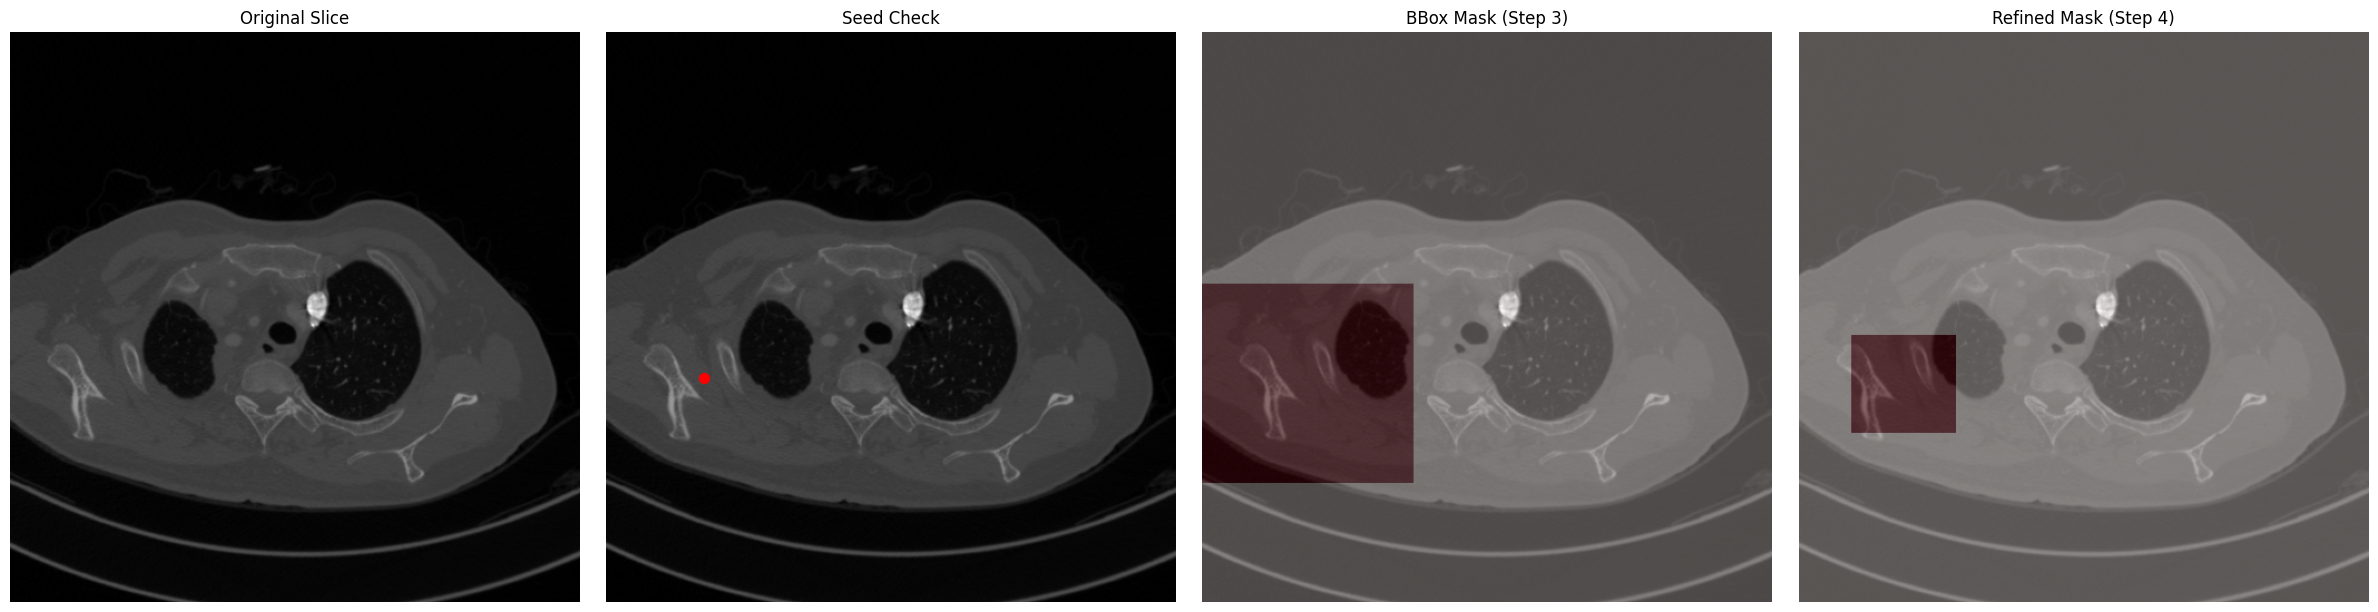


Mask unique: [0 1]
BBox voxels: 6053780
Refined voxels: 860288
Compression ratio: 0.1421075757625814


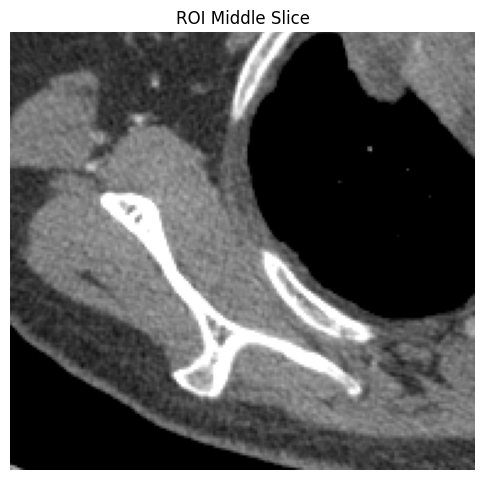

In [21]:
# ============================================================
# STEP 4 - Refined Pseudo-Mask on a Single Sample
# ============================================================

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from scipy.ndimage import (
    gaussian_filter,
    label,
    binary_opening,
    binary_closing,
    binary_fill_holes
)

# ------------------------------------------------------------
# SAMPLE SELECTION
# ------------------------------------------------------------
sample_id = "mela_0007"   # istediğin örnekle değiştir

row = df_valid[df_valid["public_id"] == sample_id]
if len(row) == 0:
    raise ValueError(f"Sample bulunamadı: {sample_id}")

row = row.iloc[0]

image_path = row["image_path"]
coordX, coordY, coordZ = int(row["coordX"]), int(row["coordY"]), int(row["coordZ"])
lx, ly, lz = int(row["x_length"]), int(row["y_length"]), int(row["z_length"])

print("Sample:", sample_id)
print("coord =", (coordX, coordY, coordZ))
print("length =", (lx, ly, lz))

# ------------------------------------------------------------
# LOAD IMAGE + CANONICAL
# ------------------------------------------------------------
img = nib.load(image_path)
img_canon = nib.as_closest_canonical(img)
img_data = img_canon.get_fdata().astype(np.float32)

# ------------------------------------------------------------
# TRUE CENTER IN ORIGINAL VOXEL SPACE
# ------------------------------------------------------------
center_old_voxel = np.array([
    coordX + lx / 2.0,
    coordY + ly / 2.0,
    coordZ + lz / 2.0,
    1.0
], dtype=np.float32)

center_world = img.affine @ center_old_voxel
center_new_voxel = np.linalg.inv(img_canon.affine) @ center_world

cx, cy, cz = center_new_voxel[:3]

print("Canonical center:", (cx, cy, cz))

# ------------------------------------------------------------
# ROI FROM BBOX SIZE
# ------------------------------------------------------------
margin = 0

x_min = max(0, int(np.floor(cx - lx / 2.0)) - margin)
x_max = min(img_data.shape[0], int(np.ceil(cx + lx / 2.0)) + margin)

y_min = max(0, int(np.floor(cy - ly / 2.0)) - margin)
y_max = min(img_data.shape[1], int(np.ceil(cy + ly / 2.0)) + margin)

z_min = max(0, int(np.floor(cz - lz / 2.0)) - margin)
z_max = min(img_data.shape[2], int(np.ceil(cz + lz / 2.0)) + margin)

roi = img_data[x_min:x_max, y_min:y_max, z_min:z_max]

print("ROI bounds:", (x_min, x_max, y_min, y_max, z_min, z_max))
print("ROI shape:", roi.shape)

if roi.size == 0:
    raise ValueError("ROI boş geldi.")

# ------------------------------------------------------------
# OPTIONAL HU CLIP
# ------------------------------------------------------------
roi = np.clip(roi, -200, 300)

# ------------------------------------------------------------
# SMOOTHING
# ------------------------------------------------------------
roi_smooth = gaussian_filter(roi, sigma=1)

# ------------------------------------------------------------
# CENTER-GUIDED LOCAL SEED
# ------------------------------------------------------------
center_seed_x = int(round(cx)) - x_min
center_seed_y = int(round(cy)) - y_min
center_seed_z = int(round(cz)) - z_min

center_seed_x = int(np.clip(center_seed_x, 0, roi.shape[0] - 1))
center_seed_y = int(np.clip(center_seed_y, 0, roi.shape[1] - 1))
center_seed_z = int(np.clip(center_seed_z, 0, roi.shape[2] - 1))

window = 8

sx_min = max(0, center_seed_x - window)
sx_max = min(roi.shape[0], center_seed_x + window + 1)

sy_min = max(0, center_seed_y - window)
sy_max = min(roi.shape[1], center_seed_y + window + 1)

sz_min = max(0, center_seed_z - window)
sz_max = min(roi.shape[2], center_seed_z + window + 1)

local_patch = roi_smooth[sx_min:sx_max, sy_min:sy_max, sz_min:sz_max]

local_idx = np.argmax(local_patch)
lx_i, ly_i, lz_i = np.unravel_index(local_idx, local_patch.shape)

seed_x = sx_min + lx_i
seed_y = sy_min + ly_i
seed_z = sz_min + lz_i

print("Center seed in ROI:", (center_seed_x, center_seed_y, center_seed_z))
print("Local intensity seed in ROI:", (seed_x, seed_y, seed_z))
print("Seed offset from center:",
      (seed_x - center_seed_x, seed_y - center_seed_y, seed_z - center_seed_z))

# ------------------------------------------------------------
# THRESHOLD
# ------------------------------------------------------------
seed_value = roi_smooth[seed_x, seed_y, seed_z]
delta = 18

lower = seed_value - delta
upper = seed_value + delta

binary_roi = (roi_smooth >= lower) & (roi_smooth <= upper)

print("Seed value:", float(seed_value))
print("Threshold range:", (float(lower), float(upper)))
print("Binary voxel count:", int(binary_roi.sum()))

# ------------------------------------------------------------
# CONNECTED COMPONENT FROM SEED
# ------------------------------------------------------------
labeled, num = label(binary_roi)
seed_label = labeled[seed_x, seed_y, seed_z]

if seed_label == 0:
    raise ValueError("Seed region bulunamadı.")

region = (labeled == seed_label)
print("Connected voxel count:", int(region.sum()))

# ------------------------------------------------------------
# MORPHOLOGY
# ------------------------------------------------------------
region = binary_opening(region)
region = binary_closing(region)
region = binary_fill_holes(region)

# ------------------------------------------------------------
# COMPONENT SELECTION: CENTER-NEAREST
# ------------------------------------------------------------
labeled2, num2 = label(region)

if num2 == 0:
    region = np.zeros_like(region, dtype=bool)
else:
    best_label = None
    best_dist = 1e9

    for lab in range(1, num2 + 1):
        coords = np.argwhere(labeled2 == lab)
        centroid = coords.mean(axis=0)
        dist = np.linalg.norm(
            centroid - np.array([center_seed_x, center_seed_y, center_seed_z])
        )
        if dist < best_dist:
            best_dist = dist
            best_label = lab

    region = (labeled2 == best_label)
    print("Chosen component distance from center:", best_dist)

# ------------------------------------------------------------
# FALLBACK IF TOO SMALL
# ------------------------------------------------------------
min_voxels = 500
method_used = "region_growing"

if region.sum() < min_voxels:
    method_used = "fallback_inner_box"

    shrink = 0.5
    half_x = int((lx * shrink) / 2)
    half_y = int((ly * shrink) / 2)
    half_z = int((lz * shrink) / 2)

    mask_full = np.zeros_like(img_data, dtype=np.uint8)

    fx_min = max(0, int(round(cx)) - half_x)
    fx_max = min(img_data.shape[0], int(round(cx)) + half_x)

    fy_min = max(0, int(round(cy)) - half_y)
    fy_max = min(img_data.shape[1], int(round(cy)) + half_y)

    fz_min = max(0, int(round(cz)) - half_z)
    fz_max = min(img_data.shape[2], int(round(cz)) + half_z)

    mask_full[fx_min:fx_max, fy_min:fy_max, fz_min:fz_max] = 1

else:
    mask_full = np.zeros_like(img_data, dtype=np.uint8)
    mask_full[x_min:x_max, y_min:y_max, z_min:z_max] = region.astype(np.uint8)

print("Method used:", method_used)

# ------------------------------------------------------------
# BBOX MASK
# ------------------------------------------------------------
bbox_mask_full = np.zeros_like(img_data, dtype=np.uint8)
bbox_mask_full[x_min:x_max, y_min:y_max, z_min:z_max] = 1

# ------------------------------------------------------------
# VISUALIZATION SLICE
# ------------------------------------------------------------
seed_global_x = x_min + seed_x
seed_global_y = y_min + seed_y
seed_global_z = z_min + seed_z

z_show = int(seed_global_z)

# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Original
axes[0].imshow(img_data[:, :, z_show].T, cmap="gray", origin="lower")
axes[0].set_title("Original Slice")
axes[0].axis("off")

# Seed Check
axes[1].imshow(img_data[:, :, z_show].T, cmap="gray", origin="lower")
axes[1].scatter(seed_global_x, seed_global_y, c="red", s=50)
axes[1].set_title("Seed Check")
axes[1].axis("off")

# BBox
axes[2].imshow(img_data[:, :, z_show].T, cmap="gray", origin="lower")
axes[2].imshow(bbox_mask_full[:, :, z_show].T, cmap="Reds", alpha=0.30, origin="lower")
axes[2].set_title("BBox Mask (Step 3)")
axes[2].axis("off")

# Refined
axes[3].imshow(img_data[:, :, z_show].T, cmap="gray", origin="lower")
axes[3].imshow(mask_full[:, :, z_show].T, cmap="Reds", alpha=0.35, origin="lower")
axes[3].set_title("Refined Mask (Step 4)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# DEBUG STATS
# ------------------------------------------------------------
print("\nMask unique:", np.unique(mask_full))
print("BBox voxels:", int(bbox_mask_full.sum()))
print("Refined voxels:", int(mask_full.sum()))
print("Compression ratio:", float(mask_full.sum()) / float(bbox_mask_full.sum()))

# ROI middle slice
roi_z_show = roi.shape[2] // 2
plt.figure(figsize=(6, 6))
plt.imshow(roi[:, :, roi_z_show].T, cmap="gray", origin="lower")
plt.title("ROI Middle Slice")
plt.axis("off")
plt.show()